In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.units import Units as U
from src.units import Units as U
import src.assumptions as A


In [2]:

# Define the data
data = {
    "Technology": [
        "CCGT (normal combined cycle)",
        "Gas Turbine (simple cycle)",
        "CCGT using E-DAC"
    ],
    "Electrical Efficiency (%)": [
        55,      # https://www.ipieca.org/resources/energy-efficiency-compendium/combined-cycle-gas-turbines-2022?
        32.5,    # https://www.powermag.com/simple-cycle-combined-cycle-or-a-hybrid-approach/?
        55
    ],
    "Waste-Heat Fraction (%)": [
        45,
        67.5,
        45
    ],
    "Waste-Heat Temperature (C)": [
        171,     # https://sites.science.oregonstate.edu/~hetheriw/energy/topics/doc/elec/natgas/cc/combined%20cycle%20product%20line%20and%20performance%20GER3574g.pdf?
        538,
        171
    ],
    "Cost (GBP per tCO2 Captured)": [
        600,
        600,
        249
    ],
}

# Create DataFrame
df = pd.DataFrame(data)

# Round numerical columns (0 decimal places)
numeric_cols = ["Electrical Efficiency (%)", "Waste-Heat Fraction (%)", "Waste-Heat Temperature (C)", "Cost (GBP per tCO2 Captured)"]
df[numeric_cols] = df[numeric_cols].apply(lambda x: np.round(x, 0).astype(int))

# Display refined table
df.style.set_caption("Summary of Efficiencies and Waste-Heat Characteristics for Gas-Based Technologies")


,Technology,Electrical Efficiency (%),Waste-Heat Fraction (%),Waste-Heat Temperature (C),Cost (GBP per tCO2 Captured)
0,CCGT (normal combined cycle),55,45,171,600
1,Gas Turbine (simple cycle),32,68,538,600
2,CCGT using E-DAC,55,45,171,249


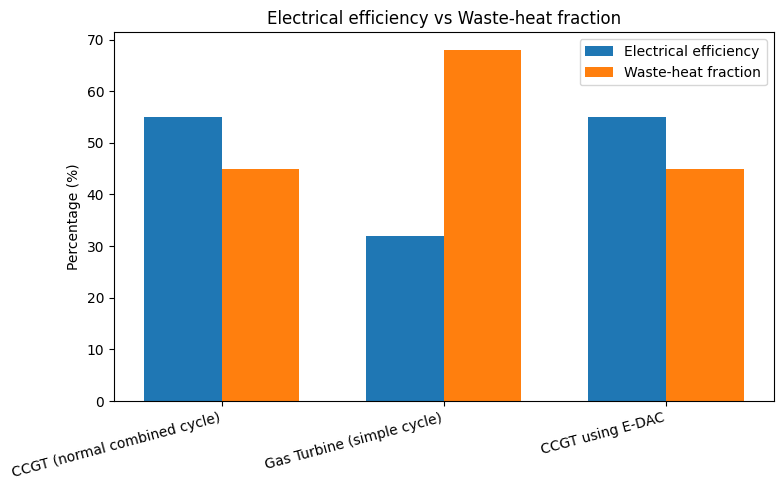

In [3]:
# Make sure the Technology column is the index for nicer plotting
df_plot = df.set_index("Technology")
df_plot


fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(df_plot.index))
width = 0.35

ax.bar(x - width/2, df_plot["Electrical Efficiency (%)"], width, label="Electrical efficiency")
ax.bar(x + width/2, df_plot["Waste-Heat Fraction (%)"], width, label="Waste-heat fraction")

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=15, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Electrical efficiency vs Waste-heat fraction")
ax.legend()
plt.tight_layout()
plt.show()


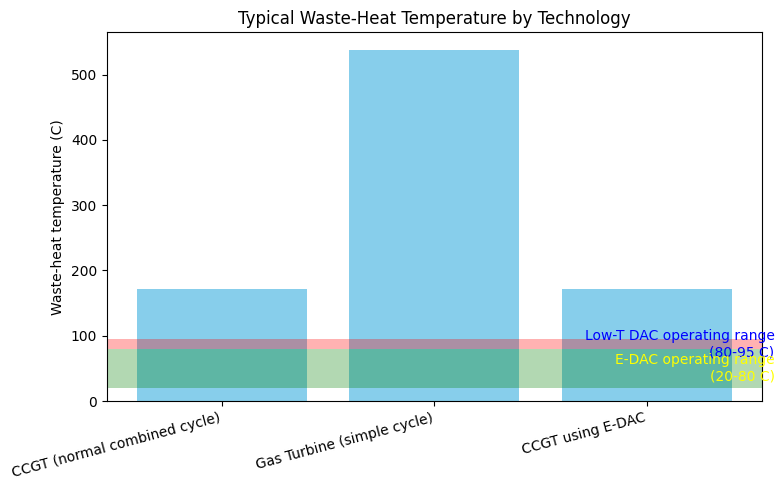

In [4]:
# Plot Waste-Heat Temperature with DAC operating range highlighted
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the bars
ax.bar(df_plot.index, df_plot["Waste-Heat Temperature (C)"], color="skyblue")

# Labeling
ax.set_ylabel("Waste-heat temperature (C)")
ax.set_title("Typical Waste-Heat Temperature by Technology")
plt.xticks(rotation=15, ha="right")

# --- Add DAC operating range 80-95 C ---
ax.axhspan(80, 95, color='red', alpha=0.3, linewidth=0)  # shaded band
ax.axhspan(20, 80, color='green', alpha=0.3, linewidth=0) # E-DAC operating range

# Text label
ax.text(len(df_plot.index)-0.4, 87.5, "Low-T DAC operating range\n(80-95 C)",
        va='center', ha='right', fontsize=10, color='blue')

ax.text(len(df_plot.index)-0.4, 50, "E-DAC operating range\n(20-80 C)",
        va='center', ha='right', fontsize=10, color='Yellow')

plt.tight_layout()
plt.show()


In [5]:
# %% [markdown]
# # Waste-Heat-Powered DAC with Electricity Demand
# 
# This notebook explores how much low-temperature DAC (80–95 °C)
# can be powered using **waste heat** from gas-based power generation
# (CCGT, GT, and CCGT without steam bottoming cycle),
# and how much **electricity** DAC requires (0.44 MWh/tCO2).
# 
# It then compares:
# - Gas CO2 emissions
# - CO2 removed via DAC (using waste heat)
# - Net CO2 balance after DAC
# - Electricity used by DAC vs electricity produced by gas
# %%

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 120


In [6]:
# %% [markdown]
# ## 1. Technology assumptions
#
# Efficiencies and waste-heat fractions for each gas technology.

# %%
tech_data = {
    "Technology": [
        "CCGT (normal combined cycle)",
        "Gas Turbine (simple cycle)",
        "CCGT with E-DAC"
    ],
    # Electrical efficiencies (fraction, not %)
    "eta_elec": [0.55, 0.325, 0.55],
    # Approximate waste-heat fraction (1 - efficiency)
    "waste_fraction": [0.45, 0.675, 0.45],
    # Representative exhaust temperatures in °C
    "T_waste_C": [171, 538, 171]
}

tech_df = pd.DataFrame(tech_data).set_index("Technology")
tech_df


,eta_elec,waste_fraction,T_waste_C
Technology,,,
CCGT (normal combined cycle),0.550,0.450,171
Gas Turbine (simple cycle),0.325,0.675,538
CCGT with E-DAC,0.550,0.450,171


In [7]:
# %% [markdown]
# ## 2. DAC and emission parameters
#
# - Low-T DAC heat requirement: 366 kWh/tCO2 (0.366 MWh/tCO2)
# - DAC electricity requirement: 0.44 MWh/tCO2 (given from model: ElectricityPerTonCO2)
# - Gas CO2 intensity: 0.34 tCO2/MWh
# - f_lowT: fraction of total waste heat usable at 80–95 °C.

# %%
# DAC heat demand
H_DAC_KWH_PER_T = 366           # kWh/tCO2 (regeneration heat at ~80–100 °C)

H_DAC_MWH_PER_T = H_DAC_KWH_PER_T / 1000  # MWh/tCO2

# DAC electricity demand (from your model: ElectricityPerTonCO2 = 0.44 * U.MWh / U.t_mt)
DAC_ELECTRICITY_MWH_PER_T = 0.44   # MWh/tCO2

dac_elec_mwh_per_t = {
    "CCGT (normal combined cycle)": 0.44,
    "Gas Turbine (simple cycle)": 0.44,
    "CCGT with E-DAC": 1.25,
}

# Gas CO2 intensity (tCO2 per MWh of electricity generated)
GAS_CO2_INTENSITY = 0.34

# DAC cost (£ per tonne CO2 captured)
DAC_COST_PER_T = 600   # £600/tCO2

# E-DAC
DAC_EDAC_COST_PER_T = 249   # £249/tCO2
E_DAC_ELECTRICITY_MWH_PER_T = 1.25  # MWh/tCO2 (estimated)


# Fraction of total waste heat that is low-T usable (tunable assumptions)
f_lowT = {
    "CCGT (normal combined cycle)": 0.10,   # stack heat ~80–150 °C
    "Gas Turbine (simple cycle)": 0.15,     # can be cooled down via HX
}

f_lowT


{'CCGT (normal combined cycle)': 0.1, 'Gas Turbine (simple cycle)': 0.15}

In [8]:
# 1) Find required annual generation (TWh) directly using assumed capacity factor
capacity = 79 * U.GW
capacity_factor = 0.85  # Adjust as needed, 1.0 represents theoretical maximum
annual_gen = (capacity * A.HoursPerYear * capacity_factor).to(U.TWh)
print("Annual generation:", annual_gen)

Annual generation: 588.6369000000001 terawatt_hour


In [9]:
# %% [markdown]
# ## 3. Define a test scenario (annual generation)
#
# These are example annual electricity outputs (TWh/year).
# Later you can replace them with real outputs from your UK energy model.

# %%
scenario_generation_TWh = {
    "CCGT (normal combined cycle)": 588,   # TWh/year
    "Gas Turbine (simple cycle)": 588,      # TWh/year
    "CCGT with E-DAC": 588 # TWh/year
}

gen_series = pd.Series(scenario_generation_TWh, name="E_elec_TWh")
gen_series


CCGT (normal combined cycle)    588
Gas Turbine (simple cycle)      588
CCGT with E-DAC                 588
Name: E_elec_TWh, dtype: int64

In [10]:
# Technology assumptions (use new name everywhere)
tech_data = {
    "Technology": [
        "CCGT (normal combined cycle)",
        "Gas Turbine (simple cycle)",
        "CCGT with E-DAC",
    ],
    "eta_elec": [0.55, 0.325, 0.35],
    "waste_fraction": [0.45, 0.675, 0.65],
    "T_waste_C": [171, 538, 538],
}
tech_df = pd.DataFrame(tech_data).set_index("Technology")

# f_lowT uses the same keys
f_lowT = {
    "CCGT (normal combined cycle)": 0.10,
    "Gas Turbine (simple cycle)": 0.15,
    "CCGT with E-DAC": 1,
}

# Scenario generation uses the same keys
scenario_generation_TWh = {
    "CCGT (normal combined cycle)": 588,
    "Gas Turbine (simple cycle)": 588,
    "CCGT with E-DAC": 588,
}
gen_series = pd.Series(scenario_generation_TWh)

# DAC electricity demand uses the same keys
dac_elec_mwh_per_t = {
    "CCGT (normal combined cycle)": 0.44,
    "Gas Turbine (simple cycle)": 0.44,
    "CCGT with E-DAC": 1.25,
}


In [11]:
# Rebuild results (adjust data/parameters as in your notebook)
tech_df = pd.DataFrame({
    "Technology": [
        "CCGT (normal combined cycle)",
        "Gas Turbine (simple cycle)",
        "CCGT with E-DAC",
    ],
    "eta_elec": [0.55, 0.325, 0.35],
    "waste_fraction": [0.45, 0.675, 0.65],
}).set_index("Technology")

f_lowT = {
    "CCGT (normal combined cycle)": 0.5,
    "Gas Turbine (simple cycle)": 0.5,
    "CCGT with E-DAC": 1,
}
dac_elec_mwh_per_t = {
    "CCGT (normal combined cycle)": 0.44,
    "Gas Turbine (simple cycle)": 0.44,
    "CCGT with E-DAC": 1.25,
}
scenario_generation_TWh = {
    "CCGT (normal combined cycle)": 150,
    "Gas Turbine (simple cycle)": 20,
    "CCGT with E-DAC": 10,
}
H_DAC_MWH_PER_T = 0.366
GAS_CO2_INTENSITY = 0.34  # tCO2/MWh
DAC_COST_PER_T = 600      # GBP/tCO2, if needed

gen_series = pd.Series(scenario_generation_TWh)
results = tech_df.copy()
results["E_elec_TWh"] = gen_series
results["E_elec_MWh"] = results["E_elec_TWh"] * 1e6
results["E_fuel_MWh"] = results["E_elec_MWh"] / results["eta_elec"]
results["E_waste_total_MWh"] = results["E_fuel_MWh"] * results["waste_fraction"]
results["f_lowT"] = [f_lowT[idx] for idx in results.index]
results["E_waste_lowT_MWh"] = results["E_waste_total_MWh"] * results["f_lowT"]
results["DAC_capture_tCO2"] = results["E_waste_lowT_MWh"] / H_DAC_MWH_PER_T
results["DAC_capture_MtCO2"] = results["DAC_capture_tCO2"] / 1e6
results["Gas_emissions_tCO2"] = results["E_elec_MWh"] * GAS_CO2_INTENSITY
results["Gas_emissions_MtCO2"] = results["Gas_emissions_tCO2"] / 1e6
results["DAC_elec_MWh_per_t"] = [dac_elec_mwh_per_t[idx] for idx in results.index]
results["E_DAC_electricity_MWh"] = results["DAC_capture_tCO2"] * results["DAC_elec_MWh_per_t"]
results["E_DAC_electricity_TWh"] = results["E_DAC_electricity_MWh"] / 1e6  # new
results["Net_emissions_MtCO2"] = (results["Gas_emissions_tCO2"] - results["DAC_capture_tCO2"]) / 1e6
results["Elec_surplus_after_DAC_TWh"] = (results["E_elec_MWh"] - results["E_DAC_electricity_MWh"]) / 1e6


tech_edac = "CCGT with E-DAC"

# Ensure columns exist
results["DAC_capture_tCO2"] = results.get("DAC_capture_tCO2", 0)
results["DAC_capture_MtCO2"] = results.get("DAC_capture_MtCO2", 0)
results["Net_emissions_MtCO2"] = results.get("Net_emissions_MtCO2", 0)

# replace DAC capture with total emissions for E-DAC tech
results.loc[tech_edac, "DAC_capture_tCO2"] = results.loc[tech_edac, "Gas_emissions_tCO2"]
results.loc[tech_edac, "DAC_capture_MtCO2"] = results.loc[tech_edac, "Gas_emissions_MtCO2"]

# Recalculate DAC electricity demand (using your per-ton electricity consumption: dac_elec_mwh_per_t)
results.loc[tech_edac, "E_DAC_electricity_MWh"] = (
    results.loc[tech_edac, "DAC_capture_tCO2"] * results.loc[tech_edac, "DAC_elec_MWh_per_t"]
)
results.loc[tech_edac, "E_DAC_electricity_TWh"] = results.loc[tech_edac, "E_DAC_electricity_MWh"] / 1e6

# Recalculate net emissions (should be 0 if capture fully offsets emissions)
results.loc[tech_edac, "Net_emissions_MtCO2"] = (
    results.loc[tech_edac, "Gas_emissions_tCO2"] - results.loc[tech_edac, "DAC_capture_tCO2"]
) / 1e6



In [12]:
edac = "CCGT with E-DAC"
elec_per_t = dac_elec_mwh_per_t[edac]  # 1.25 MWh/tCO2

# only using electricity, not waste heat
results.loc[edac, "E_waste_total_MWh"] = 0
results.loc[edac, "E_waste_lowT_MWh"] = 0

# maximum capture based on available electricity
capture_from_power = results.loc[edac, "E_elec_MWh"] / elec_per_t

# actual capture = min(emissions, capture limit) → net zero
results.loc[edac, "DAC_capture_tCO2"] = min(
    capture_from_power,
    results.loc[edac, "Gas_emissions_tCO2"]
)
results.loc[edac, "DAC_capture_MtCO2"] = results.loc[edac, "DAC_capture_tCO2"] / 1e6

# corresponding DAC electricity consumption
results.loc[edac, "E_DAC_electricity_MWh"] = results.loc[edac, "DAC_capture_tCO2"] * elec_per_t
results.loc[edac, "E_DAC_electricity_TWh"] = results.loc[edac, "E_DAC_electricity_MWh"] / 1e6

# net 0 
results.loc[edac, "Net_emissions_MtCO2"] = 0
results.loc[edac, "Elec_surplus_after_DAC_TWh"] = (
    results.loc[edac, "E_elec_MWh"] - results.loc[edac, "E_DAC_electricity_MWh"]
) / 1e6


In [13]:


# Map each technology to its efficiency and waste-heat fraction
techs = {
    name: {
        "eff": row["eta_elec"] * U.dimensionless,
        "waste_frac": row["waste_fraction"] * U.dimensionless,
    }
    for name, row in tech_df[["eta_elec", "waste_fraction"]].iterrows()
}

gross_emission_intensity = GAS_CO2_INTENSITY * U.t / U.MWh

rows = []
for tech, gen_twh in scenario_generation_TWh.items():
    gen = gen_twh * U.TWh
    p = techs[tech]
    fuel_input = gen / p["eff"]
    waste_heat = fuel_input * p["waste_frac"]
    usable_heat = waste_heat * f_lowT[tech]

    gross_emissions = (gen.to(U.MWh) * gross_emission_intensity).to(U.Mt)
    captured = (usable_heat.to(U.MWh) / H_DAC_MWH_PER_T).to(U.Mt)
    if tech == "CCGT with E-DAC":
        captured = gross_emissions  # forced net-zero
    net_emissions = (gross_emissions - captured).to(U.Mt)

    # cost calculation using magnitudes to avoid unit conversion
    captured_t = captured.to(U.t).magnitude
    cost_gbp = captured_t * DAC_COST_PER_T.magnitude

    rows.append({
        "Technology": tech,
        "Generation_TWh": gen.to(U.TWh).magnitude,
        "Fuel_input_TWh": fuel_input.to(U.TWh).magnitude,
        "Waste_heat_TWh": waste_heat.to(U.TWh).magnitude,
        "Usable_lowT_heat_TWh": usable_heat.to(U.TWh).magnitude,
        "Gas_emissions_MtCO2": gross_emissions.magnitude,
        "DAC_capture_MtCO2": captured.magnitude,
        "Net_emissions_MtCO2": net_emissions.magnitude,
        "DAC_cost_GBP": cost_gbp,
    })

df = pd.DataFrame(rows)
display(df.style.format({
    "Generation_TWh": "{:.0f}",
    "Fuel_input_TWh": "{:.1f}",
    "Waste_heat_TWh": "{:.1f}",
    "Usable_lowT_heat_TWh": "{:.1f}",
    "Gas_emissions_MtCO2": "{:.2f}",
    "DAC_capture_MtCO2": "{:.2f}",
    "Net_emissions_MtCO2": "{:.2f}",
    "DAC_cost_GBP": "£{:.1f}",
}).set_caption("Gas techs: generation, heat, emissions, and DAC cost (E-DAC forced net-zero)"))

DimensionalityError: Cannot convert from 'megawatt_hour' ([mass] * [length] ** 2 / [time] ** 2) to 'megametric_ton' ([mass])

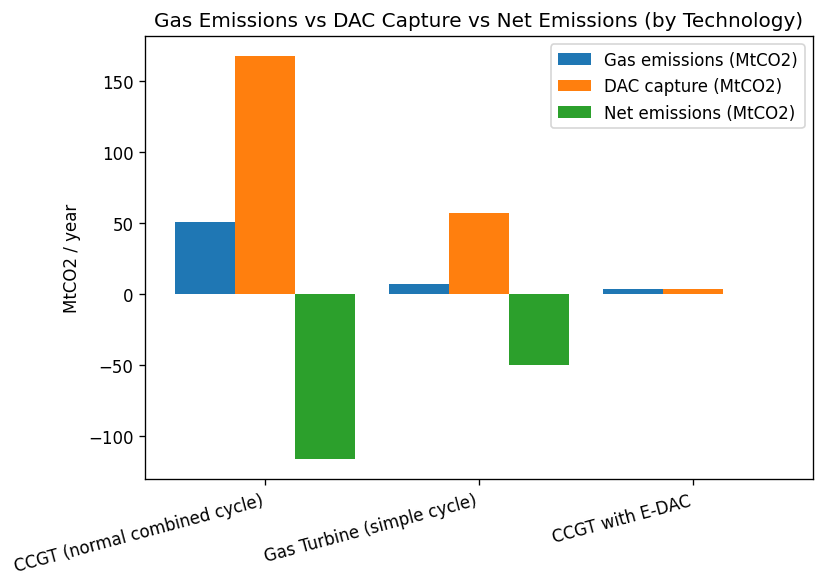

In [14]:
# Ensure net emissions column exists
if "Net_emissions_MtCO2" not in results.columns:
    results["Net_emissions_MtCO2"] = results["Gas_emissions_MtCO2"] - results["DAC_capture_MtCO2"]

fig, ax = plt.subplots()
x = np.arange(len(results.index))
width = 0.28

ax.bar(x - width, results["Gas_emissions_MtCO2"], width, label="Gas emissions (MtCO2)")
ax.bar(x, results["DAC_capture_MtCO2"], width, label="DAC capture (MtCO2)")
ax.bar(x + width, results["Net_emissions_MtCO2"], width, label="Net emissions (MtCO2)")

ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=15, ha="right")
ax.set_ylabel("MtCO2 / year")
ax.set_title("Gas Emissions vs DAC Capture vs Net Emissions (by Technology)")
ax.legend()
plt.tight_layout()
plt.show()


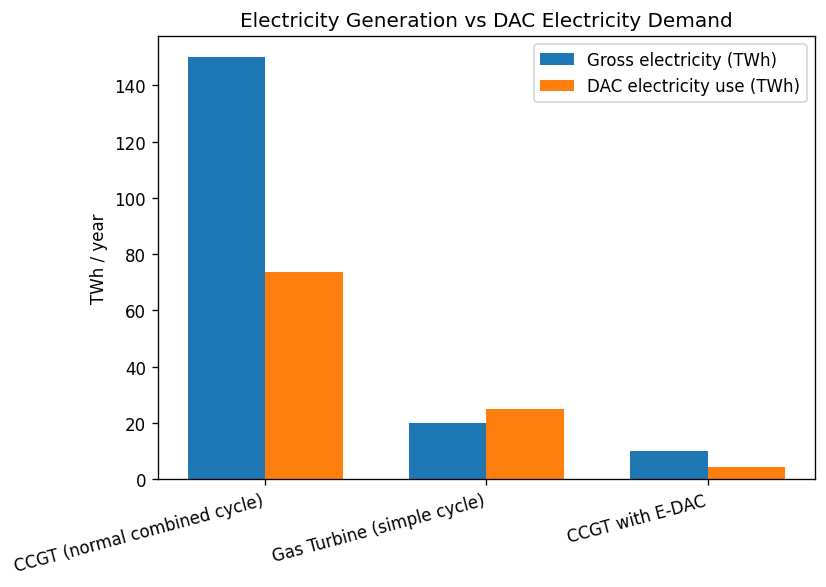

In [15]:
# %% [markdown]
# ## 7. Plot: Electricity generation vs DAC electricity use
#
# This shows how much of each technology's electricity would be consumed by DAC auxiliaries.

# %%
fig, ax = plt.subplots()

x = np.arange(len(results.index))
width = 0.35

ax.bar(x - width/2, results["E_elec_TWh"], width, label="Gross electricity (TWh)")
ax.bar(x + width/2, results["E_DAC_electricity_TWh"], width, label="DAC electricity use (TWh)")

ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=15, ha="right")
ax.set_ylabel("TWh / year")
ax.set_title("Electricity Generation vs DAC Electricity Demand")
ax.legend()
plt.tight_layout()
plt.show()



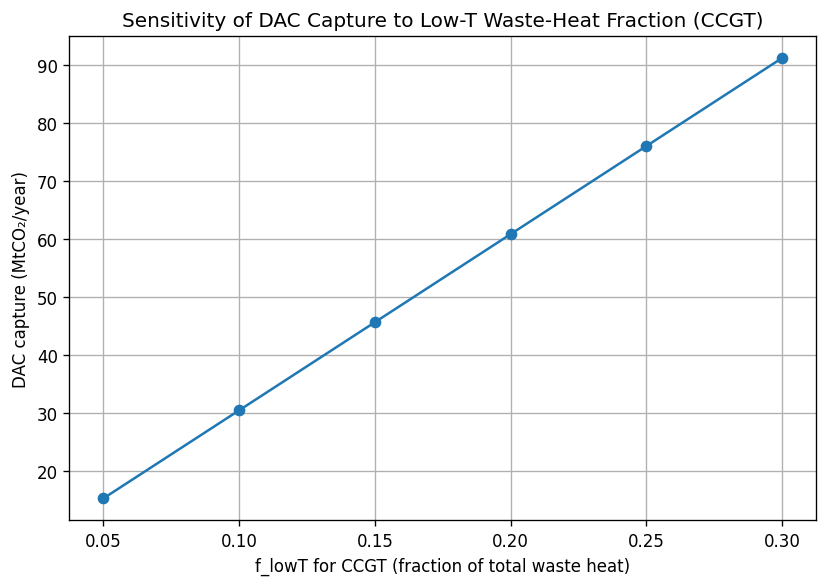

In [16]:
# %% [markdown]
# ## 8. Sensitivity: vary f_lowT for CCGT
#
# Example: vary CCGT low-T waste-heat fraction between 0.05 and 0.30
# and see how DAC capture (MtCO2/year) changes.

from src.units import Units as U  # ensure this import exists
H_DAC_MWH_PER_T = 0.366 * U.MWh / U.t  # DAC heat requirement
GAS_CO2_INTENSITY = 0.34 * U.t / U.MWh


# %%
tech = "CCGT (normal combined cycle)"
f_values = np.linspace(0.05, 0.30, 6)
captures = []

E_elec_MWh_q = results.loc[tech, "E_elec_MWh"] * U.MWh  # give it units
eta = results.loc[tech, "eta_elec"] * U.dimensionless
waste_frac = results.loc[tech, "waste_fraction"] * U.dimensionless

for f in f_values:
    E_fuel_MWh = E_elec_MWh_q / eta
    E_waste_total_MWh = E_fuel_MWh * waste_frac
    E_waste_lowT_MWh = E_waste_total_MWh * f
    DAC_capture_t = E_waste_lowT_MWh / H_DAC_MWH_PER_T  # units of t
    DAC_capture_Mt = DAC_capture_t.to(U.Mt).magnitude   # strip units for plotting
    captures.append(DAC_capture_Mt)

# Plot results
fig, ax = plt.subplots()
ax.plot(f_values, captures, marker="o")
ax.set_xlabel("f_lowT for CCGT (fraction of total waste heat)")
ax.set_ylabel("DAC capture (MtCO₂/year)")
ax.set_title("Sensitivity of DAC Capture to Low-T Waste-Heat Fraction (CCGT)")
ax.grid(True)
plt.tight_layout()
plt.show()


CCGT (normal combined cycle) usable heat (TWh): [0.0 8.181818181818182 16.363636363636363 24.545454545454547 32.72727272727273 40.90909090909091] terawatt_hour
Gas Turbine (simple cycle) usable heat (TWh): [0.0 31.153846153846153 62.30769230769231 93.46153846153847 124.61538461538461 155.76923076923075] terawatt_hour
CCGT with E-DAC usable heat (TWh): [0.0 0.0 0.0 0.0 0.0 0.0] terawatt_hour


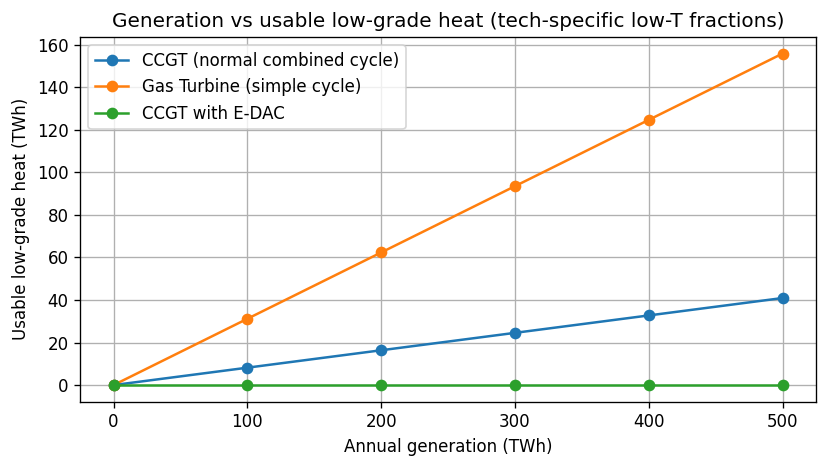

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from src.units import Units as U

# annual generation (TWh)
gen = np.array([0, 100, 200, 300, 400, 500]) * U.TWh

# parameters for each technology
techs = {
    "CCGT (normal combined cycle)": {"eff": 0.55, "waste_frac": 0.45},
    "Gas Turbine (simple cycle)": {"eff": 0.325, "waste_frac": 0.675},
    "CCGT with E-DAC": {"eff": 0.35, "waste_frac": 0.65},
}

# fraction of low-temperature usable waste heat (by technology)
f_lowT = {
    "CCGT (normal combined cycle)": 0.10,   # stack heat ~80–150 °C
    "Gas Turbine (simple cycle)": 0.15,     # can be cooled via HX
    "CCGT with E-DAC": 0,
}

fig, ax = plt.subplots(figsize=(7, 4))

for name, p in techs.items():
    fuel_input = gen / p["eff"]  # fuel input (TWh equivalent)
    usable_heat = fuel_input * p["waste_frac"] * f_lowT[name]  # usable low-grade heat
    print(f"{name} usable heat (TWh):", usable_heat.to(U.TWh))
    ax.plot(gen.to(U.TWh).magnitude, usable_heat.to(U.TWh).magnitude, marker="o", label=name)

ax.set_xlabel("Annual generation (TWh)")
ax.set_ylabel("Usable low-grade heat (TWh)")
ax.set_title("Generation vs usable low-grade heat (tech-specific low-T fractions)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


CCGT (normal combined cycle) usable heat (TWh): [0.0 4.090909090909091 8.181818181818182 12.272727272727272 16.363636363636363 20.454545454545453 24.545454545454543 28.636363636363637 32.72727272727273 36.81818181818182] terawatt_hour
CCGT (normal combined cycle) net emissions (MtCO2): [0.0 -6.964772262459017 -13.929544524918034 -20.894316787377043 -27.85908904983607 -34.82386131229508 -41.78863357475409 -48.753405837213116 -55.71817809967214 -62.68295036213116] megametric_ton
Gas Turbine (simple cycle) usable heat (TWh): [0.0 10.384615384615385 20.76923076923077 31.153846153846157 41.53846153846154 51.92307692307693 62.307692307692314 72.6923076923077 83.07692307692308 93.46153846153847] terawatt_hour
Gas Turbine (simple cycle) net emissions (MtCO2): [0.0 -22.564647420088278 -45.129294840176556 -67.69394226026482 -90.25858968035311 -112.82323710044137 -135.38788452052964 -157.95253194061792 -180.51717936070622 -203.08182678079444] megametric_ton
CCGT with E-DAC usable heat (TWh): [0.0

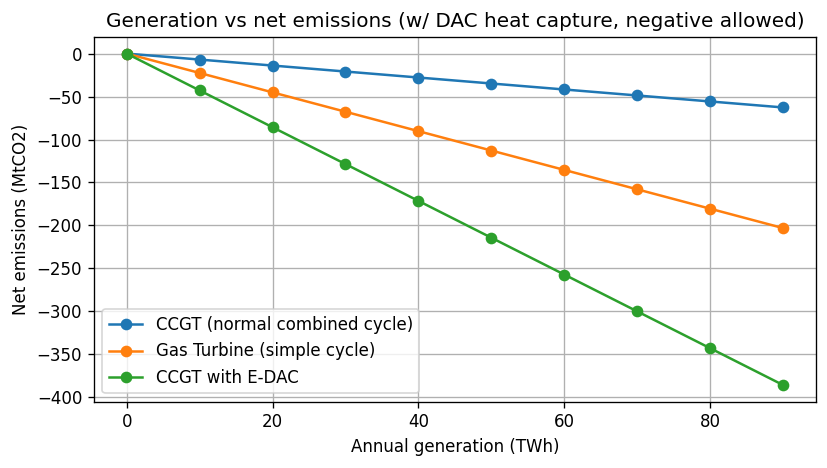

In [18]:

# annual generation（TWh）
gen = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90]) * U.TWh

# parameters for each technology
techs = {
    "CCGT (normal combined cycle)": {"eff": 0.55, "waste_frac": 0.45},
    "Gas Turbine (simple cycle)": {"eff": 0.325, "waste_frac": 0.675},
    "CCGT with E-DAC": {"eff": 0.35, "waste_frac": 0.65},
}

# usable fraction of low-temperature heat (varies by technology)
f_lowT = {
    "CCGT (normal combined cycle)": 0.5,
    "Gas Turbine (simple cycle)": 0.5,
    "CCGT with E-DAC": 1,
}

# DAC heat consumption
H_DAC_KWH_PER_T = 366
H_DAC_MWH_PER_T = H_DAC_KWH_PER_T / 1000 * U.MWh / U.t

# Gross emission intensity (uncaptured, tCO2/MWh)
gross_emission_intensity = 0.35 * U.t / U.MWh

fig, ax = plt.subplots(figsize=(7, 4))

for name, params in techs.items():
    fuel_input = gen / params["eff"]  # Fuel input (TWh equivalent)
    usable_heat = fuel_input * params["waste_frac"] * f_lowT[name]  # Usable low-grade heat (TWh)

    gross_emissions = (gen.to(U.MWh) * gross_emission_intensity).to(U.Mt)
    captured = (usable_heat.to(U.MWh) / H_DAC_MWH_PER_T).to(U.Mt)
    net_emissions = (gross_emissions - captured).to(U.Mt)  # Negative allowed

    print(f"{name} usable heat (TWh):", usable_heat.to(U.TWh))
    print(f"{name} net emissions (MtCO2):", net_emissions)

    ax.plot(gen.to(U.TWh).magnitude, net_emissions.magnitude, marker="o", label=name)

ax.set_xlabel("Annual generation (TWh)")
ax.set_ylabel("Net emissions (MtCO2)")
ax.set_title("Generation vs net emissions (w/ DAC heat capture, negative allowed)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()